# 1차원 Cubic 데이터 신경망 회귀 모델 PyTorch 상세 주석 버전

이 노트북은 입력값 `x`와 출력값 `y` 사이의 관계가 **3차 함수(cubic function)** 인 데이터를 생성한 뒤, PyTorch 기반의 다층 신경망으로 이 비선형 관계를 학습하는 실습입니다.

원래 목표 함수는 다음과 같습니다.

\[
y = x^3 - 3x^2 - 9x - 1
\]

현실 데이터처럼 완벽한 함수값만 존재하지 않고 오차가 포함된 데이터를 만들기 위해 정규분포 기반의 noise를 추가합니다. 이후 신경망이 noisy data를 보고 원래의 곡선 패턴을 얼마나 잘 근사하는지 확인합니다.

이 코드는 다음 목적을 가집니다.

1. PyTorch Tensor로 1차원 회귀 데이터를 생성합니다.
2. 3차 함수 형태의 비선형 데이터를 만듭니다.
3. 다층 신경망을 구성하여 비선형 함수를 학습합니다.
4. 손실 함수와 Optimizer를 사용하여 모델을 훈련합니다.
5. 학습된 예측 결과와 손실 감소 그래프를 시각화합니다.
6. 학습 후 모델의 가중치와 편향을 확인합니다.

## 1. 필요한 라이브러리 불러오기

이 단계에서는 데이터 생성, 신경망 모델 구성, 학습, 시각화에 필요한 라이브러리를 불러옵니다.

- `torch`는 PyTorch의 핵심 라이브러리입니다.
- `torch.nn`은 신경망 계층과 손실 함수를 제공합니다.
- `torch.optim`은 SGD, Adam 같은 최적화 알고리즘을 제공합니다.
- `matplotlib.pyplot`은 학습 데이터와 예측 결과를 그래프로 확인하기 위해 사용합니다.
- `numpy`는 일부 배열 변환 및 보조 연산에 사용합니다.

기존 코드에서 사용되던 `Variable`은 최신 PyTorch에서는 Tensor 자체가 자동 미분 기능을 지원하므로 사용하지 않습니다. 또한 `visdom` 대신 별도 서버가 필요 없는 `matplotlib`을 사용하여 Google Colab이나 Jupyter Notebook에서 바로 실행되도록 구성합니다.

In [ ]:
# ============================================================
# 1. 필요한 라이브러리 불러오기
# ============================================================

# NumPy는 배열 처리와 일부 수치 계산을 보조하기 위해 사용합니다.
import numpy as np

# PyTorch의 핵심 라이브러리입니다.
# Tensor 생성, GPU 연산, 자동 미분 등을 처리합니다.
import torch

# torch.nn은 신경망 계층(Linear, ReLU 등)과 손실 함수(L1Loss 등)를 제공합니다.
import torch.nn as nn

# torch.optim은 SGD, Adam 같은 Optimizer를 제공합니다.
# Optimizer는 역전파로 계산된 gradient를 이용해 가중치와 편향을 수정합니다.
import torch.optim as optim

# matplotlib은 데이터를 그래프로 시각화하기 위해 사용합니다.
import matplotlib.pyplot as plt

# 실행할 장치를 자동으로 선택합니다.
# CUDA GPU가 사용 가능하면 GPU를 사용하고, 그렇지 않으면 CPU를 사용합니다.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 현재 선택된 실행 장치를 출력합니다.
# Colab에서 GPU 런타임을 켜면 cuda가 출력될 수 있습니다.
print("현재 사용 장치:", device)

# 실험 결과가 매번 비슷하게 나오도록 난수 시드를 고정합니다.
# 난수 시드를 고정하면 데이터 생성과 모델 초기화 결과가 재현 가능해집니다.
torch.manual_seed(42)
np.random.seed(42)

# GPU에서도 가능한 한 재현성을 높이기 위한 설정입니다.
# 완전한 재현성은 환경에 따라 달라질 수 있지만, 교육용 실습에서는 유용합니다.
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

현재 사용 장치: cpu


## 2. 하이퍼파라미터 설정

하이퍼파라미터는 모델이 학습하기 전에 사람이 직접 정하는 설정값입니다.

이 예제에서는 다음 값을 사용합니다.

- `num_data`: 생성할 데이터 개수입니다.
- `num_epoch`: 전체 데이터를 몇 번 반복해서 학습할지 정합니다.
- `learning_rate`: 가중치를 한 번에 얼마나 크게 수정할지 정합니다.
- `noise_std`: 실제 데이터에 추가할 noise의 표준편차입니다.

3차 함수는 값의 범위가 커질 수 있으므로 학습률을 너무 크게 설정하면 손실이 발산할 수 있습니다. 따라서 비교적 작은 학습률을 사용합니다.

In [ ]:
# ============================================================
# 2. 하이퍼파라미터 설정
# ============================================================

# 생성할 학습 데이터의 개수입니다.
# 값이 클수록 모델이 더 많은 예제를 보고 학습할 수 있지만, 학습 시간이 길어질 수 있습니다.
num_data = 1000

# 학습 반복 횟수입니다.
# 1 epoch는 전체 학습 데이터를 한 번 모두 사용하여 학습하는 것을 의미합니다.
num_epoch = 5000

# 학습률입니다.
# 학습률이 너무 크면 학습이 불안정해지고, 너무 작으면 학습 속도가 느려집니다.
learning_rate = 0.0005

# 데이터에 추가할 noise의 표준편차입니다.
# noise가 클수록 데이터가 원래 함수 곡선에서 더 많이 흩어집니다.
noise_std = 0.5

## 3. Cubic 데이터 생성

이 단계에서는 신경망이 학습할 데이터를 직접 생성합니다.

입력 데이터 `x`는 -10부터 10 사이에서 균등하게 생성합니다. 출력 데이터 `y`는 다음 3차 함수로 계산합니다.

\[
y = x^3 - 3x^2 - 9x - 1
\]

그리고 실제 데이터처럼 약간의 불규칙성을 주기 위해 noise를 더합니다.

\[
y_{noise} = y + noise
\]

모델은 `x`를 입력받아 `y_noise`를 예측하도록 학습합니다.

In [ ]:
# ============================================================
# 3. Cubic 데이터 생성
# ============================================================

# torch.rand(num_data, 1)는 0 이상 1 미만의 균등분포 난수를 생성합니다.
# 여기에 20을 곱하고 10을 빼면 값의 범위가 -10 이상 10 미만이 됩니다.
# shape은 (1000, 1)이므로 1개의 입력 특성을 가진 데이터 1000개를 의미합니다.
x = torch.rand(num_data, 1) * 20 - 10

# 3차 함수의 실제 정답값을 계산합니다.
# ** 연산자는 거듭제곱을 의미합니다.
# x**3은 x의 세제곱, x**2는 x의 제곱입니다.
y = (x ** 3) - 3 * (x ** 2) - 9 * x - 1

# 정규분포를 따르는 noise를 생성합니다.
# torch.randn_like(y)는 y와 같은 모양의 난수 Tensor를 만듭니다.
# 여기에 noise_std를 곱해 noise의 크기를 조절합니다.
noise = torch.randn_like(y) * noise_std

# 실제 정답 함수값 y에 noise를 더해 관측 데이터 y_noise를 만듭니다.
# 실제 머신러닝 데이터는 보통 완벽한 함수값이 아니라 오차가 포함된 관측값입니다.
y_noise = y + noise

# 모델 학습에 사용하기 위해 입력과 정답을 선택한 device로 이동합니다.
# GPU가 사용 가능하면 GPU 메모리로 이동하고, 아니면 CPU에 남습니다.
x_train = x.to(device)
y_train = y_noise.to(device)

# 생성된 데이터의 크기를 확인합니다.
# x_train과 y_train이 모두 (1000, 1) 형태인지 확인합니다.
print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)

x_train shape: torch.Size([1000, 1])
y_train shape: torch.Size([1000, 1])


## 4. 생성된 데이터 시각화

이 단계에서는 생성된 학습 데이터를 그래프로 확인합니다.

- 파란 점은 noise가 포함된 학습 데이터입니다.
- 빨간 선은 원래 3차 함수의 실제 곡선입니다.

이 그래프를 보면 데이터가 직선이 아니라 휘어진 곡선 형태임을 확인할 수 있습니다. 따라서 단순 선형회귀보다 비선형 표현이 가능한 신경망이 필요합니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54632 (\N{HANGUL SYLLABLE HAM}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49688 (\N{HANGUL SYLLABLE SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45936 (\N{HANGUL SYLLABLE DE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/loca

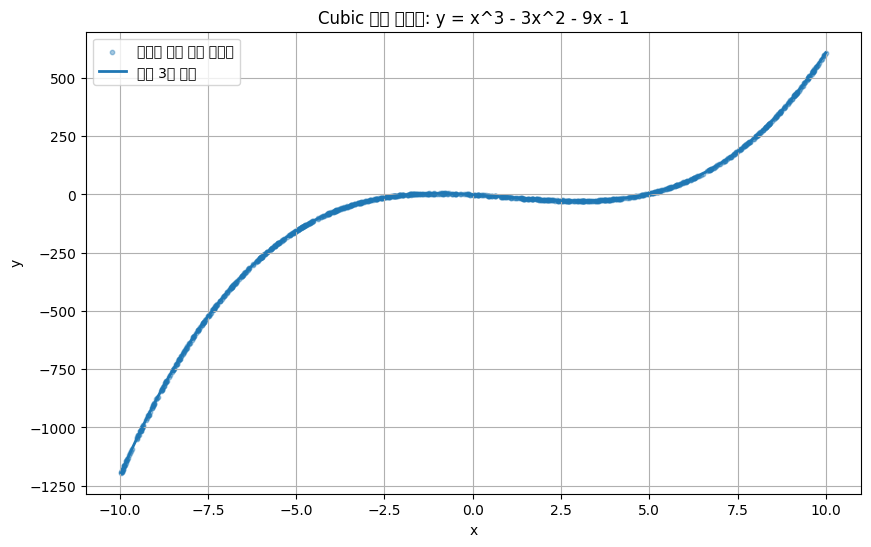

In [ ]:
# ============================================================
# 4. 생성 데이터 시각화
# ============================================================

# 그래프를 그리기 위해 Tensor를 CPU로 이동한 뒤 NumPy 배열로 변환합니다.
# matplotlib은 GPU Tensor를 직접 그릴 수 없으므로 .cpu().numpy()가 필요합니다.
x_np = x.cpu().numpy()
y_np = y.cpu().numpy()
y_noise_np = y_noise.cpu().numpy()

# x값을 기준으로 정렬합니다.
# 선 그래프를 자연스럽게 그리려면 x가 작은 값부터 큰 값 순서로 정렬되어야 합니다.
sorted_idx = np.argsort(x_np.reshape(-1))
x_sorted = x_np.reshape(-1)[sorted_idx]
y_sorted = y_np.reshape(-1)[sorted_idx]

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 6))

# noise가 포함된 학습 데이터를 산점도로 표시합니다.
plt.scatter(x_np, y_noise_np, s=10, alpha=0.4, label="노이즈 포함 학습 데이터")

# 원래 3차 함수 곡선을 선으로 표시합니다.
plt.plot(x_sorted, y_sorted, linewidth=2, label="원래 3차 함수")

# 그래프 제목을 설정합니다.
plt.title("Cubic 함수 데이터: y = x^3 - 3x^2 - 9x - 1")

# x축 이름을 설정합니다.
plt.xlabel("x")

# y축 이름을 설정합니다.
plt.ylabel("y")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시하여 값의 위치를 보기 쉽게 합니다.
plt.grid(True)

# 그래프를 화면에 출력합니다.
plt.show()

## 5. 신경망 모델 정의

이 모델은 입력값 1개를 받아 출력값 1개를 예측하는 회귀 모델입니다.

구조는 다음과 같습니다.

```text
입력층: 1개 입력
 ↓
은닉층 1: 20개 뉴런 + ReLU
 ↓
은닉층 2: 10개 뉴런 + ReLU
 ↓
은닉층 3: 5개 뉴런 + ReLU
 ↓
출력층: 1개 출력
```

3차 함수는 직선이 아니므로 은닉층과 ReLU 활성화 함수를 사용하여 비선형 관계를 학습합니다.

## 실습 1 : 활성함수 변경 테스트



In [ ]:
# ============================================================
# 5. 신경망 모델 정의
# ============================================================

# nn.Sequential은 여러 계층을 순서대로 쌓아 모델을 만드는 방법입니다.
# 입력 데이터는 위에서 아래 순서로 각 계층을 통과합니다.
model = nn.Sequential(
    # 첫 번째 선형 계층입니다.
    nn.Linear(1, 20),
    # nn.ReLU(),
    # nn.LeakyReLU(),
    # nn.Tanh(),
    nn.Sigmoid(),

    nn.Linear(20, 10),
    # nn.ReLU(),
    # nn.LeakyReLU(),
    # nn.Tanh(),
    nn.Sigmoid(),

    nn.Linear(10, 5),
    # nn.ReLU(),
    # nn.LeakyReLU(),
    # nn.Tanh(),
    nn.Sigmoid(),

    # 출력 계층입니다.
    nn.Linear(5, 1),
)

# 모델을 선택한 device로 이동합니다.
# GPU가 가능하면 모델의 파라미터가 GPU 메모리에 올라갑니다.
model = model.to(device)

# 모델 구조를 출력하여 계층 구성을 확인합니다.
print(model)

Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): Sigmoid()
  (2): Linear(in_features=20, out_features=10, bias=True)
  (3): Sigmoid()
  (4): Linear(in_features=10, out_features=5, bias=True)
  (5): Sigmoid()
  (6): Linear(in_features=5, out_features=1, bias=True)
)


## 6. 손실 함수와 Optimizer 정의

신경망은 예측값과 실제값의 차이를 줄이는 방향으로 학습합니다. 이때 차이를 계산하는 함수가 손실 함수입니다.

이 예제에서는 `nn.L1Loss()`를 사용합니다. L1Loss는 예측값과 실제값의 절댓값 차이 평균을 계산합니다.

\[
L1Loss = mean(|y_{pred} - y_{true}|)
\]

Optimizer는 손실을 줄이기 위해 모델의 가중치와 편향을 수정합니다. 여기서는 기존 코드와 동일하게 SGD를 사용합니다.

In [ ]:
# ============================================================
# 6. 손실 함수와 Optimizer 정의
# ============================================================

# L1Loss는 예측값과 실제값 사이의 절댓값 오차 평균을 계산합니다.
# 이상치에 MSELoss보다 덜 민감한 특징이 있습니다.
loss_func = nn.L1Loss()

# SGD Optimizer를 정의합니다.
# model.parameters()는 모델 내부의 모든 학습 가능한 가중치와 편향을 의미합니다.
# lr은 learning rate로, 한 번 업데이트할 때 파라미터를 얼마나 크게 수정할지 정합니다.
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

## 7. 학습 전 예측 결과 확인

모델은 학습 전에는 가중치와 편향이 무작위로 초기화되어 있습니다. 따라서 처음에는 3차 함수 형태를 거의 맞추지 못합니다.

학습 전 예측 결과를 먼저 확인하면, 학습 후 모델이 얼마나 개선되었는지 비교할 수 있습니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51204 (\N{HANGUL SYLLABLE JEON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47784 (\N{HANGUL SYLLABLE MO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 45944 (\N{HANGUL SYLLABLE DEL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/

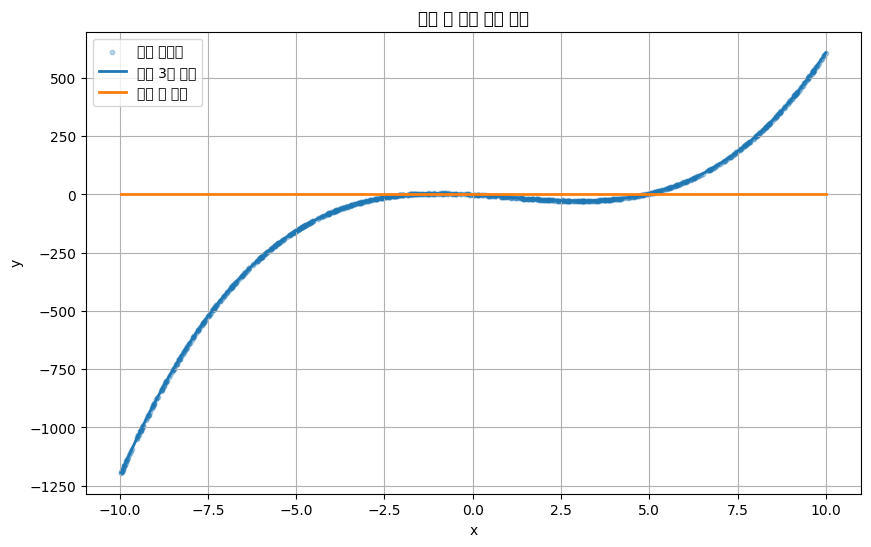

In [ ]:
# ============================================================
# 7. 학습 전 예측 결과 확인
# ============================================================

# torch.no_grad()는 gradient 계산을 비활성화합니다.
# 평가나 시각화처럼 학습하지 않는 과정에서는 메모리와 연산량을 줄이기 위해 사용합니다.
with torch.no_grad():
    # 학습 전 모델의 예측값을 계산합니다.
    # 아직 학습하지 않았으므로 예측 곡선이 실제 3차 함수와 다를 가능성이 큽니다.
    before_pred = model(x_train)

# 예측값을 그래프에 그리기 위해 NumPy 배열로 변환합니다.
before_pred_np = before_pred.cpu().numpy().reshape(-1)

# x 기준으로 예측값도 정렬합니다.
before_pred_sorted = before_pred_np[sorted_idx]

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 6))

# 학습 데이터를 산점도로 표시합니다.
plt.scatter(x_np, y_noise_np, s=10, alpha=0.3, label="학습 데이터")

# 원래 정답 곡선을 표시합니다.
plt.plot(x_sorted, y_sorted, linewidth=2, label="원래 3차 함수")

# 학습 전 모델 예측 곡선을 표시합니다.
plt.plot(x_sorted, before_pred_sorted, linewidth=2, label="학습 전 예측")

# 그래프 제목을 설정합니다.
plt.title("학습 전 모델 예측 결과")

# x축 이름을 설정합니다.
plt.xlabel("x")

# y축 이름을 설정합니다.
plt.ylabel("y")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 8. 모델 학습

이 단계는 전체 코드에서 가장 핵심적인 부분입니다.

학습 과정은 다음 순서로 진행됩니다.

1. 모델이 입력값 `x_train`을 보고 예측값을 계산합니다.
2. 예측값과 실제값 `y_train`의 차이를 손실 함수로 계산합니다.
3. `optimizer.zero_grad()`로 이전 gradient를 초기화합니다.
4. `loss.backward()`로 역전파를 수행합니다.
5. `optimizer.step()`으로 가중치와 편향을 업데이트합니다.

이 과정을 `num_epoch`만큼 반복하면서 모델은 점점 3차 함수에 가까운 형태를 학습합니다.

In [ ]:
# ============================================================
# 8. 모델 학습
# ============================================================

# epoch별 손실값을 저장할 리스트입니다.
# 학습이 진행되면서 손실이 줄어드는지 확인할 때 사용합니다.
loss_arr = []

# 지정된 epoch 수만큼 반복 학습합니다.
for epoch in range(num_epoch):
    # --------------------------------------------------------
    # 1단계: 순전파 Forward Propagation
    # --------------------------------------------------------
    # 모델에 입력값 x_train을 넣어 예측값 output을 계산합니다.
    output = model(x_train)

    # --------------------------------------------------------
    # 2단계: 손실 계산
    # --------------------------------------------------------
    # 예측값 output과 실제값 y_train 사이의 오차를 계산합니다.
    loss = loss_func(output, y_train)

    # --------------------------------------------------------
    # 3단계: 이전 gradient 초기화
    # --------------------------------------------------------
    # PyTorch는 기본적으로 gradient를 누적합니다.
    # 매 epoch마다 새 gradient만 사용하기 위해 반드시 초기화해야 합니다.
    optimizer.zero_grad()

    # --------------------------------------------------------
    # 4단계: 역전파 Backpropagation
    # --------------------------------------------------------
    # loss를 기준으로 모든 가중치와 편향에 대한 gradient를 자동 계산합니다.
    loss.backward()

    # --------------------------------------------------------
    # 5단계: 파라미터 업데이트
    # --------------------------------------------------------
    # 계산된 gradient를 이용하여 모델의 가중치와 편향을 수정합니다.
    optimizer.step()

    # 현재 epoch의 손실값을 Python float 값으로 변환하여 리스트에 저장합니다.
    # .item()은 Tensor 안의 스칼라 값을 일반 숫자로 꺼내는 함수입니다.
    loss_arr.append(loss.item())

    # 500 epoch마다 현재 손실값을 출력합니다.
    # 학습이 정상적으로 진행되면 손실값이 점점 감소하는 경향을 보입니다.
    if epoch % 500 == 0:
        print(f"Epoch [{epoch:4d}/{num_epoch}]  Loss: {loss.item():.6f}")

# 학습 완료 후 마지막 손실값을 출력합니다.
print("최종 손실값:", loss_arr[-1])

Epoch [   0/5000]  Loss: 222.011475
Epoch [ 500/5000]  Loss: 221.939468
Epoch [1000/5000]  Loss: 221.870438
Epoch [1500/5000]  Loss: 221.802017
Epoch [2000/5000]  Loss: 221.734390
Epoch [2500/5000]  Loss: 221.668198
Epoch [3000/5000]  Loss: 221.602295
Epoch [3500/5000]  Loss: 221.535843
Epoch [4000/5000]  Loss: 221.469788
Epoch [4500/5000]  Loss: 221.405243
최종 손실값: 221.3409423828125


## 9. 학습 후 예측 결과 시각화

학습이 끝난 뒤 모델의 예측 결과를 원래 함수와 비교합니다.

그래프에서 모델 예측 곡선이 원래 3차 함수 곡선과 비슷하게 따라가면 학습이 잘 된 것입니다.

단, 학습 데이터에는 noise가 포함되어 있으므로 모델이 모든 점을 완벽하게 지나가는 것이 항상 좋은 것은 아닙니다. 지나치게 모든 점을 맞추려고 하면 과적합이 발생할 수 있습니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 54980 (\N{HANGUL SYLLABLE HU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


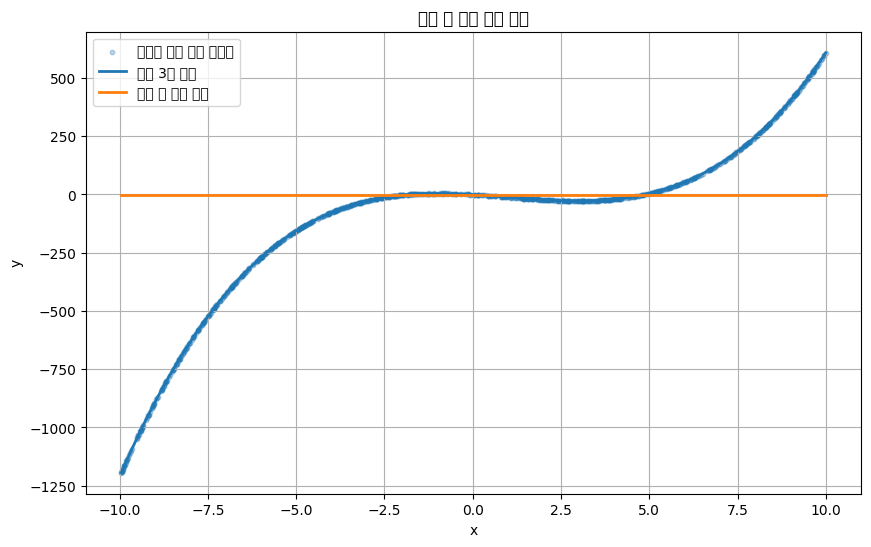

In [ ]:
# ============================================================
# 9. 학습 후 예측 결과 시각화
# ============================================================

# 학습 후 예측값을 계산합니다.
# 평가 단계이므로 gradient 계산은 필요하지 않습니다.
with torch.no_grad():
    # 학습된 모델로 입력 데이터 x_train에 대한 예측값을 계산합니다.
    trained_output = model(x_train)

# 예측 결과를 NumPy 배열로 변환합니다.
trained_output_np = trained_output.cpu().numpy().reshape(-1)

# x값 기준으로 예측 결과를 정렬합니다.
trained_output_sorted = trained_output_np[sorted_idx]

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 6))

# noise가 포함된 학습 데이터를 산점도로 표시합니다.
plt.scatter(x_np, y_noise_np, s=10, alpha=0.3, label="노이즈 포함 학습 데이터")

# 원래 3차 함수 곡선을 표시합니다.
plt.plot(x_sorted, y_sorted, linewidth=2, label="원래 3차 함수")

# 학습된 모델의 예측 곡선을 표시합니다.
plt.plot(x_sorted, trained_output_sorted, linewidth=2, label="학습 후 모델 예측")

# 그래프 제목을 설정합니다.
plt.title("학습 후 모델 예측 결과")

# x축 이름을 설정합니다.
plt.xlabel("x")

# y축 이름을 설정합니다.
plt.ylabel("y")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 10. 손실 감소 그래프 시각화

손실 그래프는 모델이 학습되는 과정을 보여줍니다.

일반적으로 학습이 잘 진행되면 epoch가 증가할수록 손실값이 감소합니다. 손실값이 계속 줄어들지 않고 흔들리거나 증가한다면 학습률이 너무 크거나 모델 구조가 적절하지 않을 수 있습니다.

/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50640 (\N{HANGUL SYLLABLE E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 46384 (\N{HANGUL SYLLABLE DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 47480 (\N{HANGUL SYLLABLE REUN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49552 (\N{HANGUL SYLLABLE SON}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/l

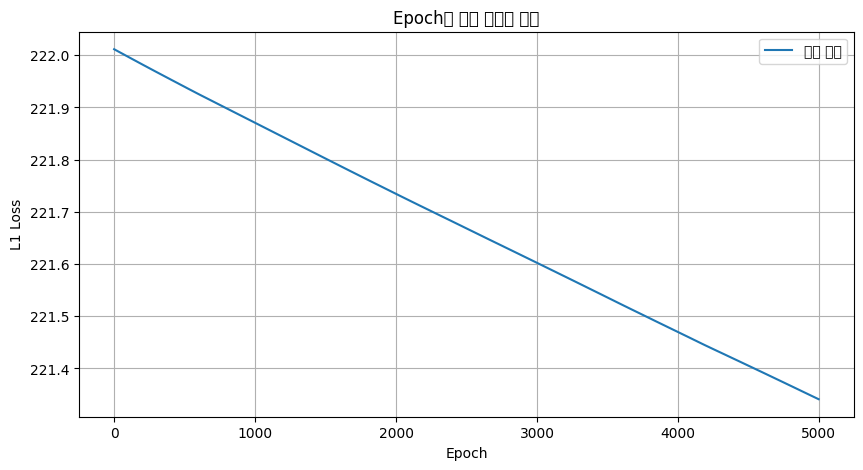

In [ ]:
# ============================================================
# 10. 손실 감소 그래프 시각화
# ============================================================

# 그래프 크기를 설정합니다.
plt.figure(figsize=(10, 5))

# epoch에 따른 loss 변화를 선 그래프로 표시합니다.
plt.plot(loss_arr, label="학습 손실")

# 그래프 제목을 설정합니다.
plt.title("Epoch에 따른 손실값 변화")

# x축 이름을 설정합니다.
plt.xlabel("Epoch")

# y축 이름을 설정합니다.
plt.ylabel("L1 Loss")

# 범례를 표시합니다.
plt.legend()

# 격자선을 표시합니다.
plt.grid(True)

# 그래프를 출력합니다.
plt.show()

## 11. 모델 파라미터 확인

신경망은 학습 과정에서 각 계층의 가중치와 편향을 자동으로 수정합니다.

`model.named_parameters()`를 사용하면 모델 내부의 모든 가중치와 편향을 확인할 수 있습니다.

- `0.weight`: 첫 번째 Linear 계층의 가중치
- `0.bias`: 첫 번째 Linear 계층의 편향
- `2.weight`: 두 번째 Linear 계층의 가중치
- `2.bias`: 두 번째 Linear 계층의 편향
- `4.weight`: 세 번째 Linear 계층의 가중치
- `4.bias`: 세 번째 Linear 계층의 편향
- `6.weight`: 출력 Linear 계층의 가중치
- `6.bias`: 출력 Linear 계층의 편향

In [ ]:
# ============================================================
# 11. 모델 파라미터 확인
# ============================================================

# named_parameters()는 모델 안의 학습 가능한 파라미터 이름과 값을 함께 반환합니다.
for name, param in model.named_parameters():
    # 파라미터 이름을 출력합니다.
    print("파라미터 이름:", name)

    # 파라미터 모양을 출력합니다.
    # 예를 들어 Linear(1, 20)의 weight shape은 (20, 1)입니다.
    print("파라미터 크기:", param.shape)

    # 파라미터 값의 일부만 출력합니다.
    # 전체 값을 모두 출력하면 너무 길어질 수 있으므로 앞부분만 확인합니다.
    print("파라미터 값 일부:")
    print(param.data.flatten()[:10])

    # 구분선을 출력합니다.
    print("-" * 60)

파라미터 이름: 0.weight
파라미터 크기: torch.Size([20, 1])
파라미터 값 일부:
tensor([ 0.8303, -0.4786, -0.4145,  0.0831,  0.2551, -0.0903,  0.6861, -0.5832,
         0.3579, -0.0112])
------------------------------------------------------------
파라미터 이름: 0.bias
파라미터 크기: torch.Size([20])
파라미터 값 일부:
tensor([-0.2697, -0.8181,  0.3804,  0.7087,  0.0800, -0.7164, -0.7572, -0.3892,
         0.2910,  0.0252])
------------------------------------------------------------
파라미터 이름: 2.weight
파라미터 크기: torch.Size([10, 20])
파라미터 값 일부:
tensor([ 0.0853,  0.1066, -0.1357, -0.2228, -0.0116, -0.0267,  0.0655, -0.0639,
         0.1711,  0.0138])
------------------------------------------------------------
파라미터 이름: 2.bias
파라미터 크기: torch.Size([10])
파라미터 값 일부:
tensor([-0.0431, -0.0926,  0.0057, -0.1630, -0.1321,  0.0019,  0.2128, -0.0603,
         0.1142, -0.0931])
------------------------------------------------------------
파라미터 이름: 4.weight
파라미터 크기: torch.Size([5, 10])
파라미터 값 일부:
tensor([-0.0464, -0.2580,  0.3147,  0.3606,  0.

## 12. 새로운 입력값에 대한 예측

학습된 모델은 훈련 데이터뿐만 아니라 새로운 x값에 대해서도 예측을 수행할 수 있습니다.

예를 들어 `x = -5, 0, 5`에 대해 모델이 어떤 값을 예측하는지 확인합니다.

In [ ]:
# ============================================================
# 12. 새로운 입력값 예측
# ============================================================

# 새롭게 예측하고 싶은 입력값을 Tensor로 생성합니다.
# shape은 (데이터개수, 입력특성수) 형태여야 하므로 (3, 1) 형태로 만듭니다.
new_x = torch.tensor([[-5.0], [0.0], [5.0]], dtype=torch.float32).to(device)

# 실제 3차 함수값도 계산하여 모델 예측과 비교합니다.
true_y = (new_x ** 3) - 3 * (new_x ** 2) - 9 * new_x - 1

# 학습된 모델로 예측합니다.
# 평가 단계이므로 no_grad를 사용합니다.
with torch.no_grad():
    pred_y = model(new_x)

# 결과를 출력합니다.
for i in range(new_x.shape[0]):
    # .item()은 Tensor의 스칼라 값을 Python 숫자로 변환합니다.
    print(f"x = {new_x[i].item():6.2f} | 실제 함수값 = {true_y[i].item():10.4f} | 모델 예측값 = {pred_y[i].item():10.4f}")

x =  -5.00 | 실제 함수값 =  -156.0000 | 모델 예측값 =    -1.6924
x =   0.00 | 실제 함수값 =    -1.0000 | 모델 예측값 =    -1.6908
x =   5.00 | 실제 함수값 =     4.0000 | 모델 예측값 =    -1.6914


## 13. 전체 코드 흐름 정리

이 노트북은 1차원 입력값 `x`로부터 3차 함수 형태의 출력값 `y`를 예측하는 신경망 회귀 모델을 구현한 예제입니다.

전체 흐름은 다음과 같습니다.

1. 필요한 라이브러리를 불러옵니다.
2. 하이퍼파라미터를 설정합니다.
3. 3차 함수 기반 데이터를 생성합니다.
4. noise를 추가하여 현실적인 학습 데이터를 만듭니다.
5. 다층 신경망 모델을 정의합니다.
6. 손실 함수와 Optimizer를 설정합니다.
7. 순전파, 손실 계산, 역전파, 파라미터 업데이트 과정을 반복합니다.
8. 학습 후 예측 결과와 손실 그래프를 시각화합니다.
9. 모델의 가중치와 편향을 확인합니다.

이 코드는 비선형 회귀 문제에서 왜 은닉층과 활성화 함수가 필요한지 이해하기 위한 교육용 실습입니다.

# 실습 리포트


## relu

Sequential(
  (0): Linear(in_features=1, out_features=20, bias=True)
  (1): ReLU()
  (2): Linear(in_features=20, out_features=10, bias=True)
  (3): ReLU()
  (4): Linear(in_features=10, out_features=5, bias=True)
  (5): ReLU()
  (6): Linear(in_features=5, out_features=1, bias=True)
)

